In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm
from functools import partial
from jax import jit, lax

jax.config.update("jax_enable_x64", True)

from JAX_BSSN.evolve import rk4_step
from JAX_BSSN.bssn import BSSNVariables, BSSNParameters, compute_momentum_constraint
from JAX_BSSN.errors import compute_hamiltonian_constraint
from JAX_BSSN.derivatives import diff1_field
from JAX_BSSN.tensor_algebra import (
    invert_3x3_metric,
    christoffel_symbols_second_kind,
    trace_tensor,
    traceless_part,
)


The goal of this notebook is to use JAX_BSSN to build the BSSN variables for a static mass density in flat spacetime.

We start by defining a function to create a spherical mass density. The functionality of this is shown below using an example with slices in the xy, yz, and xz plane.

In [15]:
radius = 6.378e6 # meters
density = 5513 # kg/m^3

x = jnp.linspace(-radius * 1.1, radius * 1.1, 50)
y = jnp.linspace(-radius * 1.1, radius * 1.1, 50)
z = jnp.linspace(-radius * 1.1, radius * 1.1, 50)

X, Y, Z = jnp.meshgrid(x, y, z, indexing='ij')

rho = jnp.where(X**2 + Y**2 + Z**2 < radius**2, density, 0)

def compute_rho_sphere(x, y, z, center, radius, uniform_density):
    center_x, center_y, center_z = center
    X, Y, Z = jnp.meshgrid(x, y, z, indexing='ij')
    rho = jnp.where((X - center_x)**2 + (Y - center_y)**2 + (Z - center_z)**2 < radius**2, uniform_density, 0)
    return rho

We also define a way to visualize slices of the spherical mass density in the xy, yz, and xz plane.

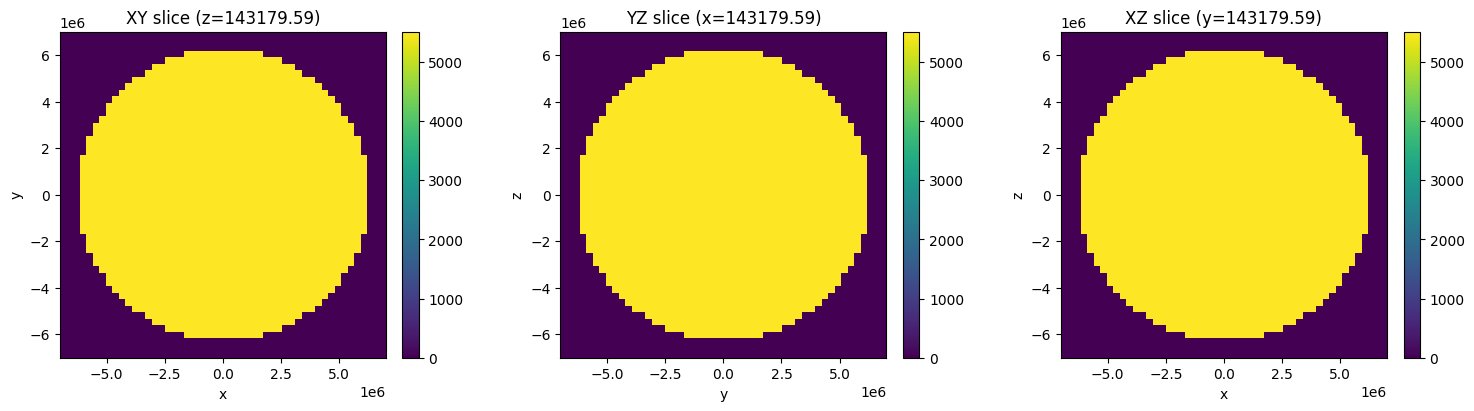

In [16]:
# Choose central slices (closest to coordinate 5)
ix = jnp.argmin(jnp.abs(x - 0))
iy = jnp.argmin(jnp.abs(y - 0))
iz = jnp.argmin(jnp.abs(z - 0))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# XY slice at fixed z
im0 = axes[0].imshow(
    rho[:, :, iz].T,
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    cmap="viridis",
    aspect="equal"
)
axes[0].set_title(f"XY slice (z={z[iz]:.2f})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# YZ slice at fixed x
im1 = axes[1].imshow(
    rho[ix, :, :].T,
    origin="lower",
    extent=[y.min(), y.max(), z.min(), z.max()],
    cmap="viridis",
    aspect="equal"
)
axes[1].set_title(f"YZ slice (x={x[ix]:.2f})")
axes[1].set_xlabel("y")
axes[1].set_ylabel("z")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# XZ slice at fixed y
im2 = axes[2].imshow(
    rho[:, iy, :].T,
    origin="lower",
    extent=[x.min(), x.max(), z.min(), z.max()],
    cmap="viridis",
    aspect="equal"
)
axes[2].set_title(f"XZ slice (y={y[iy]:.2f})")
axes[2].set_xlabel("x")
axes[2].set_ylabel("z")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

Next, we define a stress-energy tensor function for our rho and compute it.

In [17]:
def generate_stress_energy_tensor(rho):
    T = jnp.zeros((4, 4) + rho.shape)  # 4D array
    T = T.at[0, 0].set(rho)  # T_00 is mass density
    return T
T = generate_stress_energy_tensor(rho)

We will now run JAX_BSSN on a rho and try to recover newtonian potential from the lapse. We first must define relevant measurements to simulate the earth. We work in meters and geometric units:

In [18]:
# --- Unit conversion to geometric units (G = c = 1) ---
#
# The BSSN code works in geometric units where lengths are in meters.
# Earth density (SI): 5513 kg/m^3
#
# To convert mass density to geometric units (1/m^2):
#   rho_geom = (G / c^2) * rho_SI
#
# G = 6.67430e-11 m^3 kg^-1 s^-2
# c = 2.99792e8   m s^-1
# G/c^2 = 7.426e-28 m/kg

G_SI = 6.67430e-11          # m^3 kg^-1 s^-2
c_SI = 2.99792458e8         # m s^-1

# G/c^2 in m/kg
G_over_c2_m = G_SI / (c_SI**2) 

R_sphere = 6.3781e6         # meters (Earth radius)
rho_SI = 5513.0             # kg/m^3

# rho_geom has units of 1/m^2
rho_geom = G_over_c2_m * rho_SI   

M_sphere = (4.0/3.0) * jnp.pi * R_sphere**3 * rho_SI   # kg
M_geom   = G_over_c2_m * M_sphere # Dimensionless mass in units of meters

print(f'Earth density (SI):        {rho_SI:.4f} kg/m^3')
print(f'G/c^2 (m/kg):              {G_over_c2_m:.4e}')
print(f'rho_geom (1/m^2):          {rho_geom:.4e}')
print(f'Sphere mass:               {float(M_sphere):.4e} kg')
print(f'Phi/c^2 at surface ~ GM/(c^2 R) = {float(G_over_c2_m * M_sphere / R_sphere):.4e}')

Earth density (SI):        5513.0000 kg/m^3
G/c^2 (m/kg):              7.4262e-28
rho_geom (1/m^2):          4.0940e-24
Sphere mass:               5.9917e+24 kg
Phi/c^2 at surface ~ GM/(c^2 R) = 6.9763e-10


Next we define a function to run JAX_BSSN on a static planetary mass. We will be using the lapse and metric

$$\alpha = 1, d\sigma^{2}=\gamma_{\mu  \nu}dx^{\mu}dx^{\mu}$$

where the lapse represents a static spacetime and the flat metric is defined for the Minkowski spacetime metric.

We now define our RK4 steps and simulation function:

In [19]:
def run_static_mass(nx, L, dt_factor, Nt, snapshot_stride, rho_field_fn,
                    show_progress=True):
    """Evolve flat spacetime + spherical mass density in 3D BSSN.

    Initialises Minkowski initial data (alpha=1, flat metric, K=0)
    with a caller-supplied density field.

    Parameters
    ----------
    rho_field_fn : callable(coords) -> array (nx, nx, nx)
        Function that takes the 1-D coordinate array and returns the
        mass-density field in geometric units.
    """
    dx = L / nx
    dt = dt_factor * dx
    coords = -L/2 + (jnp.arange(nx) + 0.5) * dx  # cell-centred

    # Build the density on this grid via the user-supplied function
    rho_field = rho_field_fn(coords)

    x3d, y3d, z3d = jnp.meshgrid(coords, coords, coords, indexing='ij')
    r3d = jnp.sqrt(x3d**2 + y3d**2 + z3d**2)
    r3d = jnp.maximum(r3d, 1e-30)

    # Flat-space BSSN initial data
    alpha = jnp.ones((nx, nx, nx))
    beta  = jnp.zeros((3, nx, nx, nx))
    conformal_factor = jnp.ones((nx, nx, nx))

    gamma = jnp.zeros((3, 3, nx, nx, nx))
    gamma = gamma.at[0, 0].set(1.0)
    gamma = gamma.at[1, 1].set(1.0)
    gamma = gamma.at[2, 2].set(1.0)

    traceless_K = jnp.zeros((3, 3, nx, nx, nx))
    trace_K     = jnp.zeros((nx, nx, nx))
    conformal_connection = jnp.zeros((3, nx, nx, nx))

    vars = BSSNVariables(
        conformal_metric=gamma,
        conformal_factor=conformal_factor,
        traceless_K=traceless_K,
        trace_K=trace_K,
        conformal_connection=conformal_connection,
        lapse=alpha,
        shift=beta,
        rho=rho_field,
    )

    params = BSSNParameters(
        eta=0.0,
        kappa=0.0,
        nu=0.25,
        f=1.0,      # 1+log slicing -> lapse settles to ~ 1 + Phi/c^2
        g=0.0,
        dx=dx,
        dt=dt,
    )

    # Snapshot storage
    times_list = [0.0]
    lapse_snapshots = [vars.lapse]

    iterator = range(1, Nt + 1)
    if show_progress:
        iterator = tqdm(iterator, leave=False)

    for step in iterator:
        vars = rk4_step(vars, params)
        if (step % snapshot_stride == 0) or (step == Nt):
            times_list.append(step * dt)
            lapse_snapshots.append(vars.lapse)
    
    return (
        jnp.asarray(times_list),
        lapse_snapshots,
        coords,
        r3d,
        rho_field,
        dx,
    )


We now define our our resolution factors and center our computed rho before running our simulation. Be wary of edits, it currently takes almost 3.75 hours to complete a simulation at this resolution but it is the only resolution which has given me a nonzero result for the lapse.

In [20]:
# Run the static-mass evolution
L_domain = 4.0 * R_sphere    # ~25.5 million meters
nx_mass  = 64                 
dt_fac   = 0.1                # CFL factor
Nt_mass  = 1000               # 10^3 timesteps
snap_stride = 100

# Build rho_field using compute_rho_sphere
def make_rho_field(coords):
    """Create spherical density field centered at origin."""
    # Create the 3D grid from the 1D coordinate arrays provided by the solver
    X, Y, Z = jnp.meshgrid(coords, coords, coords, indexing='ij')
    
    # Calculate radial distance from the center (0,0,0)
    r_squared = X**2 + Y**2 + Z**2
    
    # Apply the density condition
    rho_field = jnp.where(r_squared < R_sphere**2, rho_geom, 0.0)
    return rho_field

print(f'Domain: [{-L_domain/2:.2f}, {L_domain/2:.2f}] m   ({nx_mass}^3 grid)')
print(f'dx = {L_domain/nx_mass:.4f} m,  dt = {dt_fac * L_domain/nx_mass:.4e} m')
print(f'Nt = {Nt_mass},  rho_geom = {rho_geom:.4e} m^-2')

times_mass, lapse_snaps, coords_mass, r3d_mass, rho_field_mass, dx_mass = run_static_mass(
    nx=nx_mass,
    L=L_domain,
    dt_factor=dt_fac,
    Nt=Nt_mass,
    snapshot_stride=snap_stride,
    rho_field_fn=make_rho_field,
    show_progress=True,
)

print(f'\nEvolution finished: {len(times_mass)} snapshots over t=[0, {float(times_mass[-1]):.4f}] m')

Domain: [-12756200.00, 12756200.00] m   (64^3 grid)
dx = 398631.2500 m,  dt = 3.9863e+04 m
Nt = 1000,  rho_geom = 4.0940e-24 m^-2


KeyboardInterrupt: 

We finally compare our code to the newtonian potential in linearized gravity. The theory is as follows:

For a uniform sphere, as a function of radius r,

$$\Phi _{in} (r) = -\frac{M}{2R} (3 - \frac{r^2}{R^2}), \Phi _{out} (r) = -\frac{M}{r}$$

In linearized gravity, we can relate this to the lapse by the following:

$$\alpha \approx 1 + \Phi \Rightarrow \Phi = \alpha - 1$$

We a manually computed value of phi below with the lapse outputted by JAX_BSSN. On the graphs, we observe that while they are off by a factor less than a single order of magnitude (~x5), they have the same shape and inflection point, a relatively successful result.

In [ ]:
# ---- Newtonian potential computed in float64 (avoids sqrt(1+2Phi)-1 cancellation) ----
M_geom_sphere_f64 = jnp.float64(4.0/3.0) * jnp.pi * jnp.float64(R_sphere)**3 * jnp.float64(rho_geom)

def newtonian_potential_f64(r, M, R):
    """Phi(r) for a uniform sphere, in float64."""
    inside  = -M / (2.0 * R) * (3.0 - r**2 / R**2)
    outside = -M / r
    return jnp.where(r <= R, inside, outside)

r_ref = jnp.linspace(0.01, 2.0 * float(R_sphere), 500)
Phi_ref_f64 = newtonian_potential_f64(r_ref, M_geom_sphere_f64, float(R_sphere))
# In linearised gravity, alpha ≈ 1 + Phi, so (alpha-1) ≈ Phi
alpha_dev_newton = Phi_ref_f64   # this IS the expected (alpha - 1) to leading order

# ---- BSSN radial lapse profile ----
alpha_final = jnp.asarray(lapse_snaps[-1], dtype=jnp.float64)
r_flat = jnp.asarray(r3d_mass).ravel()
a_flat = alpha_final.ravel()

n_bins = 60
r_edges = jnp.linspace(0, float(r_flat.max()), n_bins + 1)
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
bin_idx = jnp.digitize(r_flat, r_edges) - 1
alpha_radial = jnp.array([
    a_flat[bin_idx == i].mean() if jnp.any(bin_idx == i) else jnp.nan
    for i in range(n_bins)
])
bssn_dev = alpha_radial - 1.0

# ---- Plots ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: lapse deviation (alpha - 1)
axes.plot(r_ref, alpha_dev_newton, 'k--', lw=2,
             label=r'Newtonian $\Phi(r)$')
axes.plot(r_centers, bssn_dev, 'o-', ms=4, lw=1.2,
             label=f'BSSN $\\alpha - 1$ (t = {float(times_mass[-1]):.1f} m)')
axes.axvline(float(R_sphere), ls=':', color='grey', label=f'R = {float(R_sphere):.2e} m')
axes.set_xlabel('r [m]')
axes.set_ylabel(r'$\alpha - 1$')
axes.set_title('Lapse deviation vs Newtonian potential')
axes.legend(fontsize=9)
axes.grid(True, alpha=0.3)

# Right: zoom
# Corrected np to jnp here
Phi_surface = newtonian_potential_f64(jnp.array([float(R_sphere)]),
                                       M_geom_sphere_f64, float(R_sphere))
y_lo = 1.5 * Phi_surface
y_hi = -0.3 * Phi_surface 

axes.plot(r_ref, alpha_dev_newton, 'k--', lw=2, label=r'Newtonian $\Phi(r)$')
axes.plot(r_centers, bssn_dev, 'o-', ms=4, lw=1.2, color='tab:red',
             label=f'BSSN $\\alpha - 1$')
axes.axvline(float(R_sphere), ls=':', color='grey')
axes.set_ylim(y_lo, y_hi)
axes.set_xlabel('r [m]')
axes.set_ylabel(r'$\alpha - 1$')
axes.set_title(f'Zoomed to Newtonian scale (Φ surface ≈ {Phi_surface:.2e})')
axes.legend(fontsize=9)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n--- Precision diagnostic ---')
print(f'Newtonian Φ(R_surface) = {Phi_surface:.4e}')
bssn_surface_idx = jnp.argmin(jnp.abs(r_centers - float(R_sphere)))
print(f'BSSN (α-1) at surface  = {bssn_dev[bssn_surface_idx]:.4e}')
print(f'float64 epsilon at 1.0 = {jnp.finfo(jnp.float64).eps:.2e}')
print(f'Signal / float64 eps   = {abs(Phi_surface) / jnp.finfo(jnp.float64).eps:.1f}')

NameError: name 'lapse_snaps' is not defined

Future work will include trying to bring up the accuracy of our lapse relative to the analytic newtonian potential and eventually evolving the rho itself to model the Jeans Instability for the formation of stars.

In [3]:
@partial(jit, static_argnames=("tol", "max_iter"))
def solve_poisson_with_conjugate_gradient(rho, phi, world, tol=1e-8, max_iter=5000):
    """
    Solve Poisson's equation ∇^2 φ = 4πρ with zero Dirichlet boundary conditions.

    Args:
        rho (ndarray): Mass density field with shape (Nx+2, Ny+2, Nz+2) including ghost cells.
        phi (ndarray): Initial guess for potential with shape (Nx+2, Ny+2, Nz+2).
        world (dict): Simulation metadata with ``dx``, ``dy``, and ``dz``.
        tol (float): Residual tolerance.
        max_iter (int): Maximum number of conjugate gradient iterations.

    Returns:
        ndarray: Potential field with shape (Nx+2, Ny+2, Nz+2).
    """
    dx = world["dx"]
    dy = world["dy"]
    dz = world["dz"]

    def lapl(field):
        dfdx2 = (
            field[2:, 1:-1, 1:-1]
            + field[:-2, 1:-1, 1:-1]
            - 2.0 * field[1:-1, 1:-1, 1:-1]
        ) / (dx * dx)
        dfdy2 = (
            field[1:-1, 2:, 1:-1]
            + field[1:-1, :-2, 1:-1]
            - 2.0 * field[1:-1, 1:-1, 1:-1]
        ) / (dy * dy)
        dfdz2 = (
            field[1:-1, 1:-1, 2:]
            + field[1:-1, 1:-1, :-2]
            - 2.0 * field[1:-1, 1:-1, 1:-1]
        ) / (dz * dz)
        return dfdx2 + dfdy2 + dfdz2

    def apply_bc(field):
        field = field.at[0, :, :].set(0.0)
        field = field.at[-1, :, :].set(0.0)
        field = field.at[:, 0, :].set(0.0)
        field = field.at[:, -1, :].set(0.0)
        field = field.at[:, :, 0].set(0.0)
        field = field.at[:, :, -1].set(0.0)
        return field

    phi = apply_bc(phi)
    source = 4.0 * jnp.pi * rho[1:-1, 1:-1, 1:-1]
    r = source - lapl(phi)
    p = jnp.zeros_like(phi).at[1:-1, 1:-1, 1:-1].set(r)
    p = apply_bc(p)

    def body_fun(state):
        phi, r, p, k = state
        Ap = lapl(p)
        alpha = jnp.sum(r * r) / jnp.sum(p[1:-1, 1:-1, 1:-1] * Ap)
        phi_next = phi.at[1:-1, 1:-1, 1:-1].add(alpha * p[1:-1, 1:-1, 1:-1])
        phi_next = apply_bc(phi_next)
        r_next = r - alpha * Ap
        beta = jnp.sum(r_next * r_next) / jnp.sum(r * r)
        p_next = p.at[1:-1, 1:-1, 1:-1].set(
            r_next + beta * p[1:-1, 1:-1, 1:-1]
        )
        p_next = apply_bc(p_next)
        return phi_next, r_next, p_next, k + 1

    def cond_fun(state):
        _, r, _, k = state
        norm_r = jnp.sum(r * r)
        return jnp.logical_and(k < max_iter, norm_r > tol**2)

    phi, _, _, _ = lax.while_loop(
        cond_fun,
        body_fun,
        (phi, r, p, 0),
    )
    return apply_bc(phi)


In [4]:
# Build ghost-cell mass density and solve Poisson with CG
rho_ghost = jnp.zeros((rho_field_mass.shape[0] + 2,
                       rho_field_mass.shape[1] + 2,
                       rho_field_mass.shape[2] + 2))
rho_ghost = rho_ghost.at[1:-1, 1:-1, 1:-1].set(rho_field_mass)
phi_init = jnp.zeros_like(rho_ghost)

world = {
    "dx": dx_mass,
    "dy": dx_mass,
    "dz": dx_mass,
}

phi_ghost = solve_poisson_with_conjugate_gradient(
    rho_ghost,
    phi_init,
    world,
    tol=1e-8,
    max_iter=2000,
)
phi_cg = phi_ghost[1:-1, 1:-1, 1:-1]

# Compute radial profiles for the CG solution and analytic reference
r_flat = jnp.asarray(r3d_mass).ravel()
phi_flat = jnp.asarray(phi_cg).ravel()

n_bins = 80
r_edges = jnp.linspace(0, float(r_flat.max()), n_bins + 1)
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
bin_idx = jnp.digitize(r_flat, r_edges) - 1
phi_radial = jnp.array([
    phi_flat[bin_idx == i].mean() if jnp.any(bin_idx == i) else jnp.nan
    for i in range(n_bins)
])

phi_ref = newtonian_potential_f64(r_centers, M_geom_sphere_f64, float(R_sphere))

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(r_centers, phi_ref, 'k--', label='Analytic Newtonian φ(r)')
ax.plot(r_centers, phi_radial, 'o-', ms=4, label='CG Poisson φ(r)')
ax.axvline(float(R_sphere), ls=':', color='grey', label=f'R = {float(R_sphere):.2e} m')
ax.set_xlabel('r [m]')
ax.set_ylabel('Potential φ')
ax.set_title('Newtonian potential from conjugate gradient Poisson solver')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('CG Poisson solve complete; compare the radial profile to analytic Newtonian φ.')


NameError: name 'rho_field_mass' is not defined